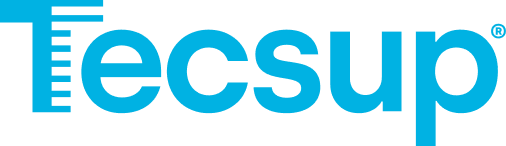

# DEPARTAMENTO DE TECNOLOGÍA DIGITAL Y GESTIÓN
## Carrera de Big Data y Ciencia de Datos
# LABORATORIO 14: CONCEPTOS PRELIMINARES. MULTICLASIFICADORES

## Integrantes:
- Joshua Jian Cora Salazar
- Kevin Estiben Olortegui Perez

- **Configuración del entorno:**

In [ ]:
# %pip install ucimlrepo polars scikit-learn pandas numpy pytest pyarrow

## 1. VARIABLES GLOBALES

In [2]:
import sys
import os
import pandas as pd
import numpy as np
import polars as pl
from typing import Dict, Tuple
from ucimlrepo import fetch_ucirepo
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# --- Configuración de la Ruta del Proyecto ---
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.insert(0, project_root)
    print(f"Proyecto raíz añadido al path: {project_root}")

Proyecto raíz añadido al path: d:\V Ciclo\MD\Semana 13\olortegui_lab13\lab13


- **Variables globales de configuración del proyecto**

In [3]:
# Ruta del dataset (aunque se descarga con ucimlrepo)
UCI_DATASET_ID = 597  # ID del dataset de Garment Employees Productivity
TARGET_THRESHOLD = 0.5  # Umbral para clasificar productividad
TEST_SIZE = 0.2  # Proporción del conjunto de prueba
RANDOM_STATE = 42  # Reproducibilidad del experimento

## 2. FUNCIONES (../src/utils.py)

In [4]:
%%writefile ../src/utils.py
import pandas as pd
import numpy as np
import polars as pl
from typing import Dict, Tuple
from ucimlrepo import fetch_ucirepo
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

def load_and_preprocess_data(dataset_id: int, threshold: float) -> Tuple[pd.DataFrame, pd.Series]:
    """
    Carga y preprocesa el dataset desde UCI ML Repository.

    Args:
        dataset_id (int): ID del dataset en ucimlrepo.
        threshold (float): Umbral para binarizar la productividad.

    Returns:
        Tuple[pd.DataFrame, pd.Series]: X preprocesado y etiquetas y.
    """
    dataset = fetch_ucirepo(id=dataset_id)
    X = pl.from_pandas(dataset.data.features)
    y = pl.from_pandas(dataset.data.targets)
    data = X.hstack(y)
    data = data.drop('date')
    actual_prod = data.select("actual_productivity").to_numpy().flatten()
    actual_prod_bin = (actual_prod >= threshold).astype(int)
    data = data.drop("actual_productivity").with_columns(
        pl.Series("actual_productivity", actual_prod_bin)
    )
    df = data.to_pandas()
    return df.drop("actual_productivity", axis=1), df["actual_productivity"]

def impute_and_encode(X: pd.DataFrame) -> Tuple[np.ndarray, pd.Index]:
    """
    Imputa datos faltantes, codifica variables categóricas y escala los datos.

    Args:
        X (pd.DataFrame): Datos sin la variable objetivo.

    Returns:
        Tuple[np.ndarray, pd.Index]: Matriz de características preprocesada y nombres de columnas.
    """
    num_cols = X.select_dtypes(include=[np.number]).columns
    imp = SimpleImputer(strategy="median")
    X[num_cols] = imp.fit_transform(X[num_cols])
    X = pd.get_dummies(X, drop_first=True)
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    return X_scaled, X.columns

def split_data(X: np.ndarray, y: pd.Series, test_size: float, random_state: int) -> Tuple:
    """
    Divide los datos en conjuntos de entrenamiento y prueba.

    Args:
        X (np.ndarray): Matriz de características.
        y (pd.Series): Etiquetas.
        test_size (float): Proporción del test set.
        random_state (int): Semilla para reproducibilidad.

    Returns:
        Tuple: X_train, X_test, y_train, y_test
    """
    return train_test_split(X, y, test_size=test_size, random_state=random_state)

def get_models_and_params() -> Tuple[Dict, Dict]:
    """
    Retorna los modelos a entrenar y sus grids de parámetros.

    Returns:
        Tuple[Dict, Dict]: Modelos y sus grids de parámetros.
    """
    from sklearn.neighbors import KNeighborsClassifier
    from sklearn.svm import SVC
    from sklearn.linear_model import LogisticRegression
    from sklearn.tree import DecisionTreeClassifier
    from sklearn.ensemble import RandomForestClassifier
    from sklearn.naive_bayes import GaussianNB

    models = {
        'KNN': KNeighborsClassifier(),
        'SVM': SVC(),
        'LogisticRegression': LogisticRegression(),
        'DecisionTree': DecisionTreeClassifier(),
        'RandomForest': RandomForestClassifier(),
        'NaiveBayes': GaussianNB()
    }

    param_grids = {
        'KNN': {'n_neighbors': [3, 5, 7]},
        'SVM': {'C': [0.1, 1, 10], 'kernel': ['linear', 'rbf']},
        'LogisticRegression': {'C': [0.01, 0.1, 1, 10]},
        'DecisionTree': {'max_depth': [3, 5, 10]},
        'RandomForest': {'n_estimators': [50, 100, 200], 'max_depth': [None, 10, 20]},
        'NaiveBayes': {}
    }
    return models, param_grids

Overwriting ../src/utils.py


## 3. IMPLEMENTACIÓN PRINCIPAL

In [5]:
from src import utils
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import GridSearchCV

### 3.1 Parte A: Preprocesamiento

In [6]:
# Llama a las funciones usando el prefijo 'utils.' ---
X_raw, y = utils.load_and_preprocess_data(UCI_DATASET_ID, TARGET_THRESHOLD)
X_scaled, feature_names = utils.impute_and_encode(X_raw)
X_train, X_test, y_train, y_test = utils.split_data(X_scaled, y, TEST_SIZE, RANDOM_STATE)

# El resto de tu código para entrenar y evaluar los modelos iría aquí
print("Datos cargados y procesados correctamente.")
print("Forma de X_train:", X_train.shape)
print("Forma de X_test:", X_test.shape)

Datos cargados y procesados correctamente.
Forma de X_train: (957, 20)
Forma de X_test: (240, 20)


### 3.2. Parte B: Entrenamiento Base

In [7]:
models, param_grids = utils.get_models_and_params()
best_models = {}
for name, model in models.items():
    print(f"\n{name} - Búsqueda de hiperparámetros")
    if param_grids[name]:
        grid = GridSearchCV(model, param_grids[name], cv=5, scoring='accuracy')
        grid.fit(X_train, y_train)
        best_models[name] = grid.best_estimator_
        print(f"Mejor accuracy: {grid.best_score_:.4f}")
        print("Mejores hiperparámetros:", grid.best_params_)
    else:
        model.fit(X_train, y_train)
        best_models[name] = model
        acc = model.score(X_test, y_test)
        print(f"Accuracy sin ajuste: {acc:.4f}")


KNN - Búsqueda de hiperparámetros
Mejor accuracy: 0.8892
Mejores hiperparámetros: {'n_neighbors': 5}

SVM - Búsqueda de hiperparámetros
Mejor accuracy: 0.8882
Mejores hiperparámetros: {'C': 1, 'kernel': 'linear'}

LogisticRegression - Búsqueda de hiperparámetros
Mejor accuracy: 0.8913
Mejores hiperparámetros: {'C': 1}

DecisionTree - Búsqueda de hiperparámetros
Mejor accuracy: 0.8924
Mejores hiperparámetros: {'max_depth': 5}

RandomForest - Búsqueda de hiperparámetros
Mejor accuracy: 0.9070
Mejores hiperparámetros: {'max_depth': 10, 'n_estimators': 100}

NaiveBayes - Búsqueda de hiperparámetros
Accuracy sin ajuste: 0.8792


### 3.3. Parte C: Optimización

In [8]:
from sklearn.metrics import accuracy_score

In [9]:
print("\nResultados en conjunto de prueba")
for name, model in best_models.items():
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print(f"\n{name}: Accuracy = {acc:.4f}")
    print(classification_report(y_test, y_pred))


Resultados en conjunto de prueba

KNN: Accuracy = 0.9042
              precision    recall  f1-score   support

           0       0.33      0.05      0.08        22
           1       0.91      0.99      0.95       218

    accuracy                           0.90       240
   macro avg       0.62      0.52      0.51       240
weighted avg       0.86      0.90      0.87       240


SVM: Accuracy = 0.9042
              precision    recall  f1-score   support

           0       0.33      0.05      0.08        22
           1       0.91      0.99      0.95       218

    accuracy                           0.90       240
   macro avg       0.62      0.52      0.51       240
weighted avg       0.86      0.90      0.87       240


LogisticRegression: Accuracy = 0.8917
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        22
           1       0.91      0.98      0.94       218

    accuracy                           0.89       240
   macr

## 4. TESTING (../tests/test_utils.py)

In [10]:
%%writefile ../tests/test_utils.py
import pytest
import numpy as np
from src.utils import load_and_preprocess_data, impute_and_encode, split_data


def test_load_and_preprocess_data():
    """
    Verifica que la carga de datos funcione, retorne DataFrames no vacíos
    y que la variable objetivo sea binaria (0 o 1).
    """
    X, y = load_and_preprocess_data(597, 0.5)
    assert not X.empty
    assert y.nunique() == 2
    assert set(y.unique()) <= {0, 1}


def test_impute_and_encode():
    """
    Verifica que la imputación y codificación retornen un array de NumPy
    con las mismas filas que el original.
    """
    X, y = load_and_preprocess_data(597, 0.5)
    X_scaled, columns = impute_and_encode(X)
    assert isinstance(X_scaled, np.ndarray)
    assert X_scaled.shape[0] == X.shape[0]
    assert len(columns) > 0


def test_split_data():
    """
    Verifica que la división de datos mantenga el número total de muestras.
    """
    X, y = load_and_preprocess_data(597, 0.5)
    X_scaled, _ = impute_and_encode(X)
    X_train, X_test, y_train, y_test = split_data(X_scaled, y, 0.2, 42)
    assert len(X_train) + len(X_test) == len(X_scaled)
    assert len(y_train) + len(y_test) == len(y)


Overwriting ../tests/test_utils.py


## 5. EJECUCIÓN

In [11]:
!pytest ../ -v

============================= test session starts =============================
platform win32 -- Python 3.13.5, pytest-8.4.0, pluggy-1.6.0 -- C:\Users\KOLORTEGUI\AppData\Local\Programs\Python\Python313\python.exe
cachedir: .pytest_cache
rootdir: d:\V Ciclo\MD\Semana 13\olortegui_lab13\lab13
configfile: pytest.ini
plugins: mock-3.14.1
collecting ... collected 3 items

..\tests\test_utils.py::test_load_and_preprocess_data PASSED             [ 33%]
..\tests\test_utils.py::test_impute_and_encode PASSED                    [ 66%]
..\tests\test_utils.py::test_split_data PASSED                           [100%]

============================== 3 passed in 9.18s ==============================
